<a href="{{ colab_base_laboratorios }}/Laboratorio_01_pinguinos_v2.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **Laboratorio N°1 — Observatorio de Datos (Pingüinos)**

- **Curso:** Aprendizaje Estadistico 2026-2
- **Estudiante:** Jerónimo López Gómez **C.C.** ******5333

**Objetivo**

Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

**Requisitos**

- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

**FASE 1 — Enfoque clásico** (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

______

- **Parte A** — Observación inicial

1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

In [24]:
import pandas as pd 
import seaborn as sns

#Load the dataset
pen_df = sns.load_dataset('penguins')

#1. Columnas y Filas Totales
print(f'Columnas Totales: {len(pen_df.columns)}\nFilas totales: {len(pen_df)}')
print('--'*50)

#2. Variables Numericas vs Categoricas
print(f"Clasificacion de Variables:")
print(f'\nColumnas Numericas')
display(pen_df.select_dtypes(include='number').columns)
print(f'Columnas Categoricas')
print(pen_df.select_dtypes(include=['category', 'str']).columns)

print('--'*50)
#3. Valores Faltantes
print(f'Datos faltantes por columna: {pen_df.isnull().sum()}')
print('--'*50)
#4. Filas Duplicadas
print(f'Filas duplicadas: {pen_df.duplicated().sum()}')
print('--'*50)
#5. Cardinalidad de Variables
print(f'Porcentaje de Cardinalidad:\n{((pen_df.nunique() / len(pen_df)).round(3)).sort_values()}')
print('--'*50)
print('Previsualización Dataset')
pen_df

Columnas Totales: 7
Filas totales: 344
----------------------------------------------------------------------------------------------------
Clasificacion de Variables:

Columnas Numericas


Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='str')

Columnas Categoricas
Index(['species', 'island', 'sex'], dtype='str')
----------------------------------------------------------------------------------------------------
Datos faltantes por columna: species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
----------------------------------------------------------------------------------------------------
Filas duplicadas: 0
----------------------------------------------------------------------------------------------------
Porcentaje de Cardinalidad:
sex                  0.006
species              0.009
island               0.009
flipper_length_mm    0.160
bill_depth_mm        0.233
body_mass_g          0.273
bill_length_mm       0.477
dtype: float64
----------------------------------------------------------------------------------------------------
Previsualización Dataset


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


______

- **Parte B** — Descripción

6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

In [25]:
#6. Estadisticos Variables Numéricas

pen_df = pen_df.dropna()

df_num = pen_df.select_dtypes(include=['number'])

num_stats = pd.DataFrame(
    {
    'Media': df_num.mean().round(2),
    'Mediana': df_num.median().round(2),
    'Desv_Est': df_num.std().round(2),
    'Rango_Intercuatil': (df_num.quantile(0.75) - df_num.quantile(0.25)).round(2)
    }
)

print(f'\nEstadisticos Variables Numericas')

num_stats


Estadisticos Variables Numericas


,Media,Mediana,Desv_Est,Rango_Intercuatil
bill_length_mm,43.99,44.5,5.47,9.1
bill_depth_mm,17.16,17.3,1.97,3.1
flipper_length_mm,200.97,197.0,14.02,23.0
body_mass_g,4207.06,4050.0,805.22,1225.0


In [26]:
#7. Conteos Variables Categoricas

df_cat = pen_df.select_dtypes(include=['str'])

cat_count = pd.DataFrame(
    {'Conteos': df_cat.value_counts(),
    'Porcentajes': (df_cat.value_counts(normalize=True)).round(3)
    })

print(f'\nConteos Variables Categoricas')

cat_count


Conteos Variables Categoricas


Conteos  Porcentajes
species   island    sex                         
Gentoo    Biscoe    Male         61        0.183
                    Female       58        0.174
Chinstrap Dream     Female       34        0.102
                    Male         34        0.102
Adelie    Dream     Male         28        0.084
                    Female       27        0.081
          Torgersen Female       24        0.072
                    Male         23        0.069
          Biscoe    Female       22        0.066
                    Male         22        0.066

In [27]:
#8. Tablas Cruzadas 

spec_sex = pd.crosstab(
    pen_df['species'],
    pen_df['sex'],
    )
spec_sex.columns.name = None
spec_sex.index.name = None

spec_isl = pd.crosstab(
    pen_df['species'],
    pen_df['island'],
    )
spec_isl.columns.name = None
spec_isl.index.name = None

isl_sex = pd.crosstab(
    pen_df['island'],
    pen_df['sex'],
    )
isl_sex.columns.name = None
isl_sex.index.name = None

print(f'Specie vs Sex Table')
display(spec_sex)
print('--'*50)
print(f'Specie vs Island Table')
display(spec_isl)
print('--'*50)
print(f'Island vs Sex Table')
display(isl_sex)

Specie vs Sex Table


,Female,Male
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


----------------------------------------------------------------------------------------------------
Specie vs Island Table


,Biscoe,Dream,Torgersen
Adelie,44,55,47
Chinstrap,0,68,0
Gentoo,119,0,0


----------------------------------------------------------------------------------------------------
Island vs Sex Table


,Female,Male
Biscoe,80,83
Dream,61,62
Torgersen,24,23


In [28]:
#9. Matrices de Correlacion

import matplotlib.pyplot as plt

spear_corr = pen_df.select_dtypes(include='number').corr(method='spearman')
pears_corr = pen_df.select_dtypes(include='number').corr(method='pearson')

print(f'Matriz de Correlación - Método Spearman')
display(spear_corr.round(3))
print('--'*50)
print(f'Matriz de Correlación - Método Pearson')
display(pears_corr.round(3))

Matriz de Correlación - Método Spearman


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.214,0.670,0.576
bill_depth_mm,-0.214,1.000,-0.517,-0.429
flipper_length_mm,0.670,-0.517,1.000,0.840
body_mass_g,0.576,-0.429,0.840,1.000


----------------------------------------------------------------------------------------------------
Matriz de Correlación - Método Pearson


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.229,0.653,0.589
bill_depth_mm,-0.229,1.000,-0.578,-0.472
flipper_length_mm,0.653,-0.578,1.000,0.873
body_mass_g,0.589,-0.472,0.873,1.000


_____

- **Parte C** — Visualización

10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

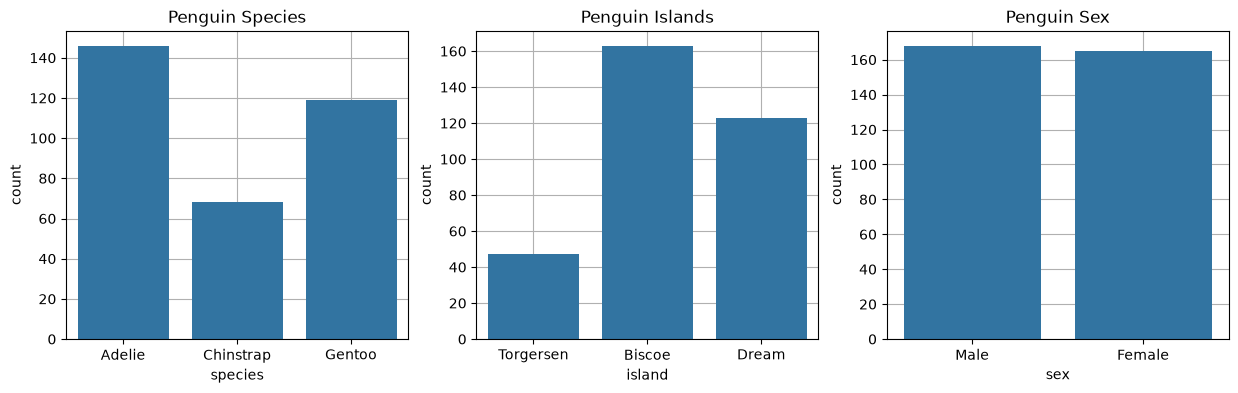

In [29]:
#10. Graficos de Conteo Variables de baja Cardinalidad

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=pen_df, x='species', zorder=2, ax=ax[0])
ax[0].set_title('Penguin Species')
ax[0].grid(zorder=1)

sns.countplot(data=pen_df, x='island', zorder=2, ax=ax[1])
ax[1].set_title('Penguin Islands')
ax[1].grid(zorder=1)

sns.countplot(data=pen_df, x='sex', zorder=2, ax=ax[2])
ax[2].set_title('Penguin Sex')
ax[2].grid(zorder=1)

plt.show()

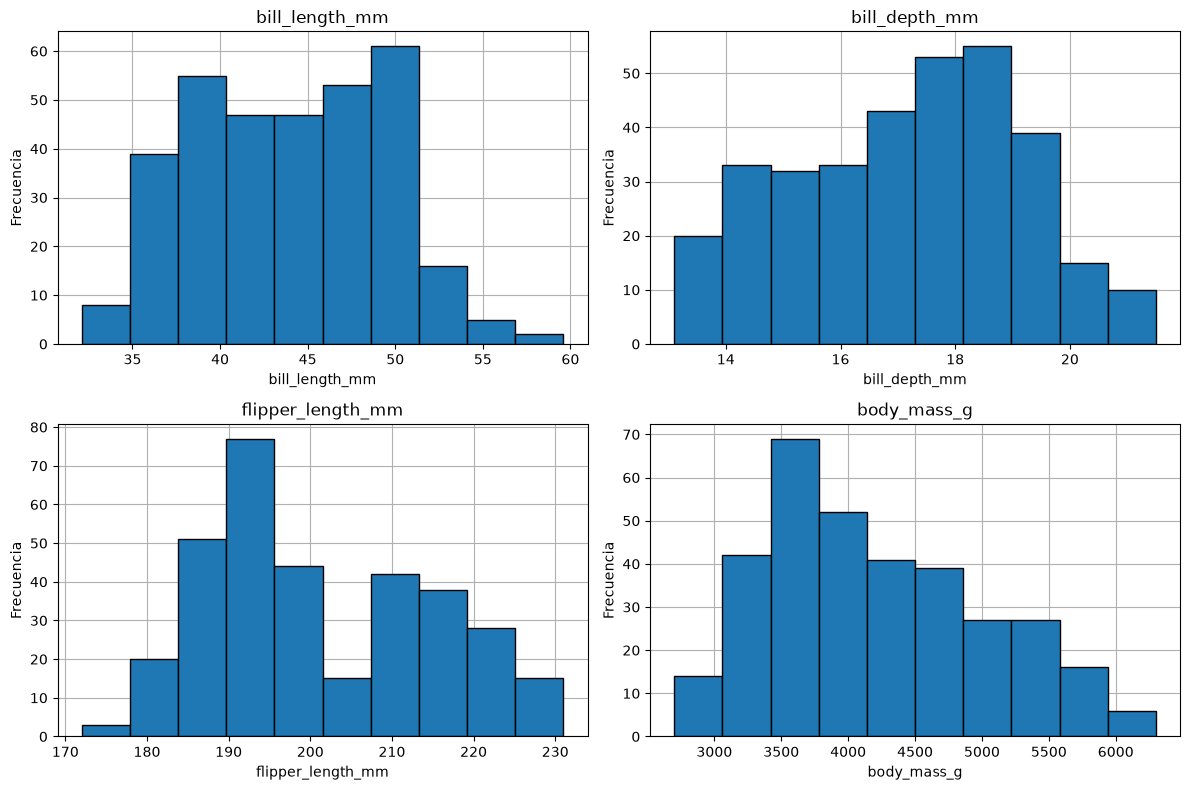

In [30]:
#11. Histogramas para Variables Numericas

num_cols = pen_df.select_dtypes(include='number').columns

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for col, axis in zip(num_cols, ax.flat):
    axis.hist(pen_df[col], bins=10, edgecolor='black', zorder=2)
    axis.set_title(f'{col}')
    axis.set_xlabel(col)
    axis.grid(zorder=1)
    axis.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

- `bill_length_mm` Presenta una distribución de datos relativamente uniforme y concentrada entre los limites de 35 y 50 aproximadamente, sin un pico predominante notable, sin sesgo aparente

- `bill_depth_mm` Presenta pico predominante alrededor de 20 donde encontramos un conjunto de datos con un leve sesgo a la izquierda

- `flipper_length_mm` Este histograma presenta una distribucion de datos alrededor de 2 picos definidos aproximadamente en 190 y 210, donde el primero es mas predominante que el segundo por 2 veces, por tanto estos datos se distribuyen alrededor de 2 zonas distintas

- `body_mass_g` presenta un histograma claramente con un sesgo a la dereca con un pico predominante alrededor de 3500 y con la mayoria de los datos distribuidos a su derecha.

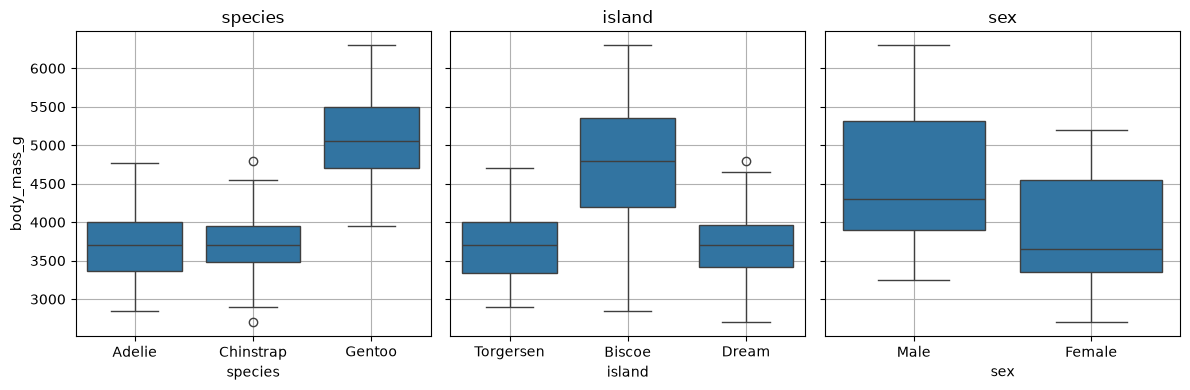

In [31]:
#12. BoxPlot de una variable numerica por categorias 

cat_cols = pen_df.select_dtypes(include='str').columns

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for col, axis in zip(cat_cols, ax.flat):
    sns.boxplot(data=pen_df, x=col, y='body_mass_g', zorder=2, ax=axis)
    axis.set_title(f'{col}')
    axis.set_xlabel(col)
    axis.grid(zorder=1)
    axis.set_xlabel(f'{col}')

plt.tight_layout()
plt.show()

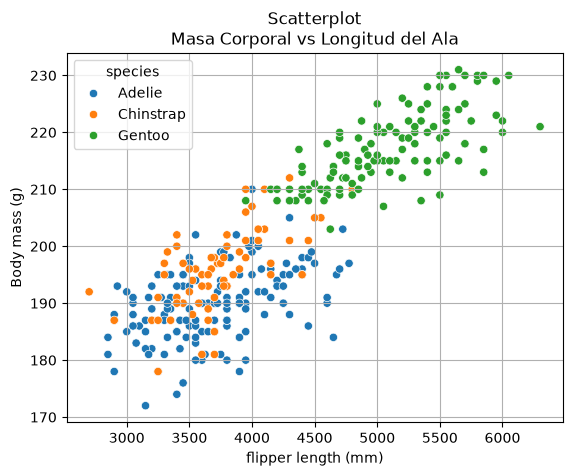

In [32]:
#13. Scatter de 2 variables numericas coloreada por una categorica

sns.scatterplot(data=pen_df, x='body_mass_g', y='flipper_length_mm', hue='species')

plt.title('Scatterplot\nMasa Corporal vs Longitud del Ala')
plt.xlabel('flipper length (mm)')
plt.ylabel('Body mass (g)')
plt.grid(zorder=1)
plt.show()

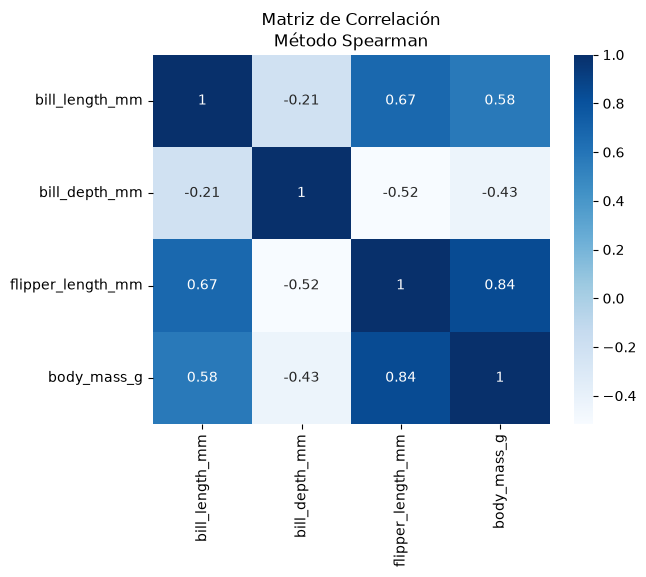

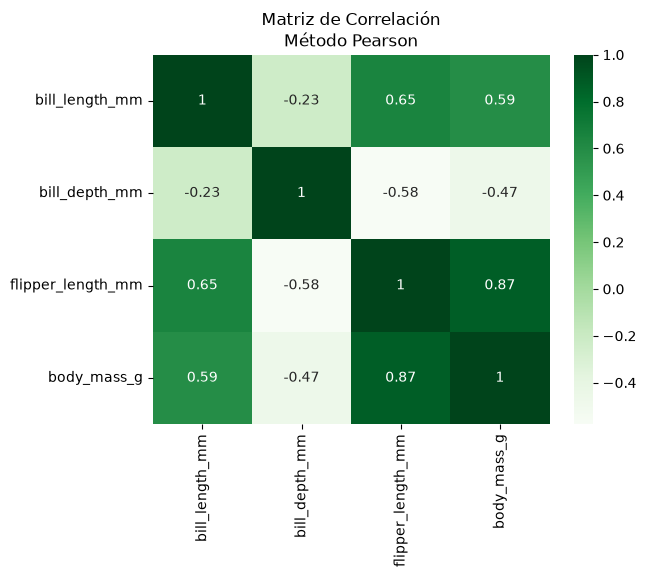

In [33]:
#14. Heatmaps de Correlacion (ver punto 9)

sns.heatmap(spear_corr, annot=True, cmap='Blues')
plt.title('Matriz de Correlación\nMétodo Spearman')
plt.show()

sns.heatmap(pears_corr, annot=True, cmap='Greens')
plt.title('Matriz de Correlación\nMétodo Pearson')
plt.show()

_______

- **Parte D** — Hipótesis (sin causalidad)

15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

**15. Respuesta**

- *Hipótesis 1:* La especie **Gentoo** agrupa especimenes de pinguinos con mayor masa corporal y aletas mas extensas.

- *Hipótesis 2:* Existe una correlación positiva entre la longitud del pico y la longitud de las alas de un pinguino.

- *Hipótesis 3:* Los pinguinos que habitan la isla **Biscoe** son mayoritariamente mas pesados que los que habitan las otras islas del estudio.

_______

- **Parte E** — Pruebas estadísticas

16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

In [85]:
#Puntos 16. 17. 18.

# Hipótesis 1: Test ANOVA
#Se tiene una variable categorica con 3 distinciones y 2 variables numericas

from scipy.stats import f_oneway, pearsonr

df_by_mas = [group['body_mass_g'].values for k, group in pen_df.groupby('species')]

df_by_flip = [group['flipper_length_mm'].values for k, group in pen_df.groupby('species')]

f_body, p_body = f_oneway(*df_by_mas)

f_flipper, p_flipper = f_oneway(*df_by_flip)

print(f'Estadistica F_body: {f_body:.4f}')
print(f'Valor p_body: {p_body}')
print('--'*50)
print(f'Estadistica F_flipper: {f_flipper:.4f}')
print(f'Valor p_flipper: {p_flipper}')

Estadistica F_body: 341.8949
Valor p_body: 3.74450512630046e-81
----------------------------------------------------------------------------------------------------
Estadistica F_flipper: 567.4070
Valor p_flipper: 1.5874180554406345e-107


In [80]:
print("Estadisticas Masa Corporal por Especie")
display(pen_df.groupby('species')['body_mass_g'].describe().round(2).sort_values('mean', ascending=False))
print('--'*50)
print("Estadisticas Longitud de Ala por Especie")
display(pen_df.groupby('species')['flipper_length_mm'].describe().round(2).sort_values('mean', ascending=False))


Estadisticas Masa Corporal por Especie


,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Gentoo,119.0,5092.44,501.48,3950.0,4700.0,5050.0,5500.0,6300.0
Chinstrap,68.0,3733.09,384.34,2700.0,3487.5,3700.0,3950.0,4800.0
Adelie,146.0,3706.16,458.62,2850.0,3362.5,3700.0,4000.0,4775.0


----------------------------------------------------------------------------------------------------
Estadisticas Longitud de Ala por Especie


,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Gentoo,119.0,217.24,6.59,203.0,212.0,216.0,221.5,231.0
Chinstrap,68.0,195.82,7.13,178.0,191.0,196.0,201.0,212.0
Adelie,146.0,190.10,6.52,172.0,186.0,190.0,195.0,210.0


**H1. Validación de Hipótesis**

Ya que el valor p_body<0.05 se valida que existen diferencias entre el peso medio de las especies, además la misma condición se satisface para la longitud del pico entre especies ya que p_flipper<0.05. Finalmente de acuerdo a los dataframes anteriores que reportan la media y estadisticas de dispersión de la misma por cada variable numérica (masa corporal y longitud de aleta) soportan la hipótesis 1: La especie **Gentoo** agrupa especimenes de pinguinos con mayor masa corporal y aletas mas extensas.

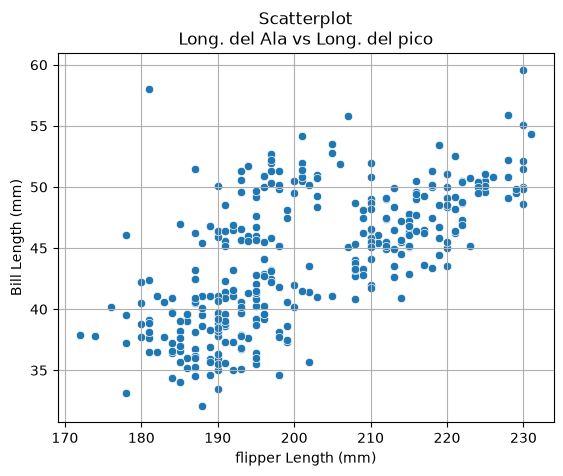

In [ ]:
# Hipótesis 2: Coef. de Pearson
#Correlación entre 2 variables numéricas

sns.scatterplot(data=pen_df,  x='flipper_length_mm',  y='bill_length_mm')

plt.title('Scatterplot\nLong. del Ala vs Long. del pico')
plt.xlabel('flipper Length (mm)')
plt.ylabel('Bill Length (mm)')
plt.grid(zorder=1)
plt.show()

In [97]:
pear_r, pear_p = pearsonr(pen_df['flipper_length_mm'], pen_df['bill_length_mm'])

print(f'Coef. Pearson: {pear_r:.4f}')
print(f'Valor P: {pear_p}')

Coef. Pearson: 0.6531
Valor P: 7.211340708097529e-42


**H2. Validación de Hipótesis**

Se obtuvo un coeficiente de pearson (r=0.65), lo que indica una correlación positiva moderada entre ambas variables (Long. Ala y Long. de Pico), además, con p<0.05 podemos rechazar la hipótesis nula. Se proporciona evidencia a favor de la hipótesis 2, indicando que los individuos con mayor longitud de aleta tienden a presentar también una mayor longitud de pico.

In [99]:
# Hipótesis 3: Test ANOVA
df_by_mas_isl = [group['body_mass_g'].values for k, group in pen_df.groupby('island')]

f_isl, p_isl = f_oneway(*df_by_mas_isl)

print(f'Estadistica F_isl: {f_isl:.4f}')
print(f'Valor p_isl: {p_isl}')

print('--'*50)

print("Estadisticas Masa Corporal por Isla")
display(pen_df.groupby('island')['body_mass_g'].describe().round(2).sort_values('mean', ascending=False))

Estadistica F_isl: 105.0587
Valor p_isl: 4.946012490756255e-36
----------------------------------------------------------------------------------------------------
Estadisticas Masa Corporal por Isla


,count,mean,std,min,25%,50%,75%,max
island,,,,,,,,
Biscoe,163.0,4719.17,790.86,2850.0,4200.0,4800.0,5350.0,6300.0
Dream,123.0,3718.90,412.94,2700.0,3412.5,3700.0,3962.5,4800.0
Torgersen,47.0,3708.51,451.85,2900.0,3337.5,3700.0,4000.0,4700.0


**H3. Validación de Hipótesis**

Del ANOVA se evidencian diferencias en la masa corporal entre las islas Dream y Torgersen en comparación con la isla Biscoe. Biscoe presenta la mayor masa corporal promedio. En conjunto con p<0.05, estos resultados proporcionan evidencia a favor de la hipótesis H3.

_____

- **Parte F** — Conclusiones y reporte

19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).


**19. Conclusiones**

**A).** Hallazgos

- La especie Gentoo presenta la mayor masa corporal promedio [**5092.44g**] y la mayor longitud de aleta promedio [**217.24 mm**], mientras que Chinstrap y Adelie presentan valores promedio considerablemente menores pero que son similares entre si, y por tanto no hay variabilidad muy profunda entre estas 2 islas dadas estas carácteristicas. Estas diferencias fueron respaldadas por los ANOVA realizados para masa corporal [**F=341.8949\ p<0.005**] y longitud de aleta [**F=567.4070\ p<0.005**], lo que se puede ser mejor visualmente apreciable en el scatterplot anterior categoriado por especies.

- Asimismo, se observó una correlación positiva entre diferentes variable numéricas. Como se puede ver según los resultados estadísticos reportados con anterioridad [**r=0.65\ p<0.005**] en pinguinos donde la longitud del pico es mayor tambien se da que la longitud de las alas tambien aumenta a medida que crece el pico de las aves. Además tambien hay una fuerte correlación positiva entre la masa corporal y la longitud de las alas como se muestra en las matrices de correlacion anteriores con coeficientes 0.84 para el método de Pearson y 0.87 con el método de Spearman. Todo lo anterior es consistente con la tendencia de que individuos con mayores dimensiones corporales tienden a presentar mayores valores en otras medidas morfológicas.

**B).** Patrones Visuales

- El gráfico de dispersión (Long. Ala vs Masa Corporal clasificado por especie) muestra una tendencia ascendente de correlación positiva con una concentración de individuos de la especie Gentoo hacia los valores altos de masa corporal y longitud de aleta, lo cuál es consistente con los resultados estadísticos de la hipótesis H1.

- Por otro lado las matrices de correlación también muestran una asociación positiva entre la mayoria de las variables numéricas a excepción de casos como la comparación de la profundidad del pico con la masa corporal y la longitud del mismo, donde la correlación es leve pero negativa. 

- De acuerdo a los anteriores BoxPlot se puede inferir que existe mayo masa corporal entre la totalidad de machos que pinguinos hembras, además que donde se encuentran los pinguinos con mayor masa corporal es en la isla Biscoe, y además como ya se habia afirmado anteriormente y formulado en las hipótesis, es que la mayor cantidad de pinguinos de alta masa corporal se encuentran dentro de la especie Gentoo.

**C).** Próximas Hipótesis a probar

A partir de estos resultados pueden plantearse nuevas hipótesis. Se podria ahondar en si la dependencia de correlación positiva entre algunas caracteristicas morfólogicas y la masa corporal se cumple dentro de cada una de las especies, también establecer una distribución poblacional de los pinguinos en cada una de las islas basada en la clasificación de sexo. Podría además investigarse si las diferencias observadas entre islas se debe a la predominancia de una especie en particular o sexualidad de pinguino.

**20. Preguntas Investigador Humano**

- ¿Cómo deberia ser la relación entre las características morfólogicas de los pinguinos y el sexo al que pertenencen?

- ¿De acuerdo a los datos aqui planteados, existe una fiable correspondencia teórica según lo planteado en la pregunta anterior?

- ¿Cómo afectaria una distribución por sexo desequilibrada en cada una de las islas a la población de pinguinos de cara hacia el futuro?

- ¿Podría considerarse mas adelante un factor de condiciones ambientales que pueda asociarse a las diferencias que se logren observar entre islas?

**Nota**: La sección de agentes sera debidamente desarrollada pero se realizará mas adelante dado que no ha sido posible llevarla a término al momento.